<a href="https://colab.research.google.com/github/RogMaverick18/Speech-Processing-Lab-assignments/blob/main/objective1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'Wav2Vec2PhonemeCTCTokenizer'. 
The class this function is called from is 'Wav2Vec2CTCTokenizer'.


Loading model: facebook/wav2vec2-lv-60-espeak-cv-ft...
Processing: objective1.wav

Detected 45 phonemes.
Sequence: ʃ iː dʒ ʌ dʒ ð ə b l uː p ɛ n p ʊ ɾ ɪ ɾ ɔ n ð ɐ t t eɪ b əl æ n d k w aɪ t l i w ɪ z p ɜː ɾ i ə s


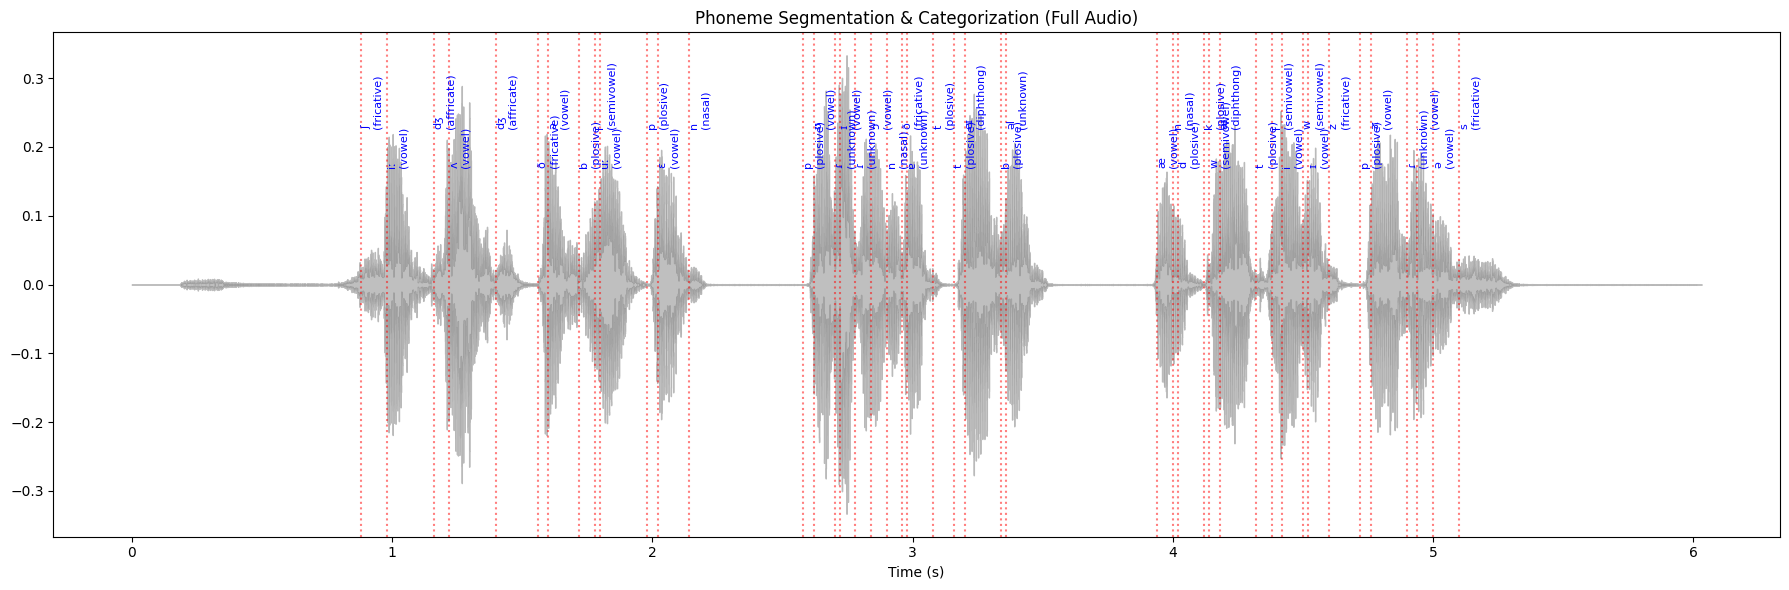


--- EXTRACTING ALL INDIVIDUAL SEGMENTS ---


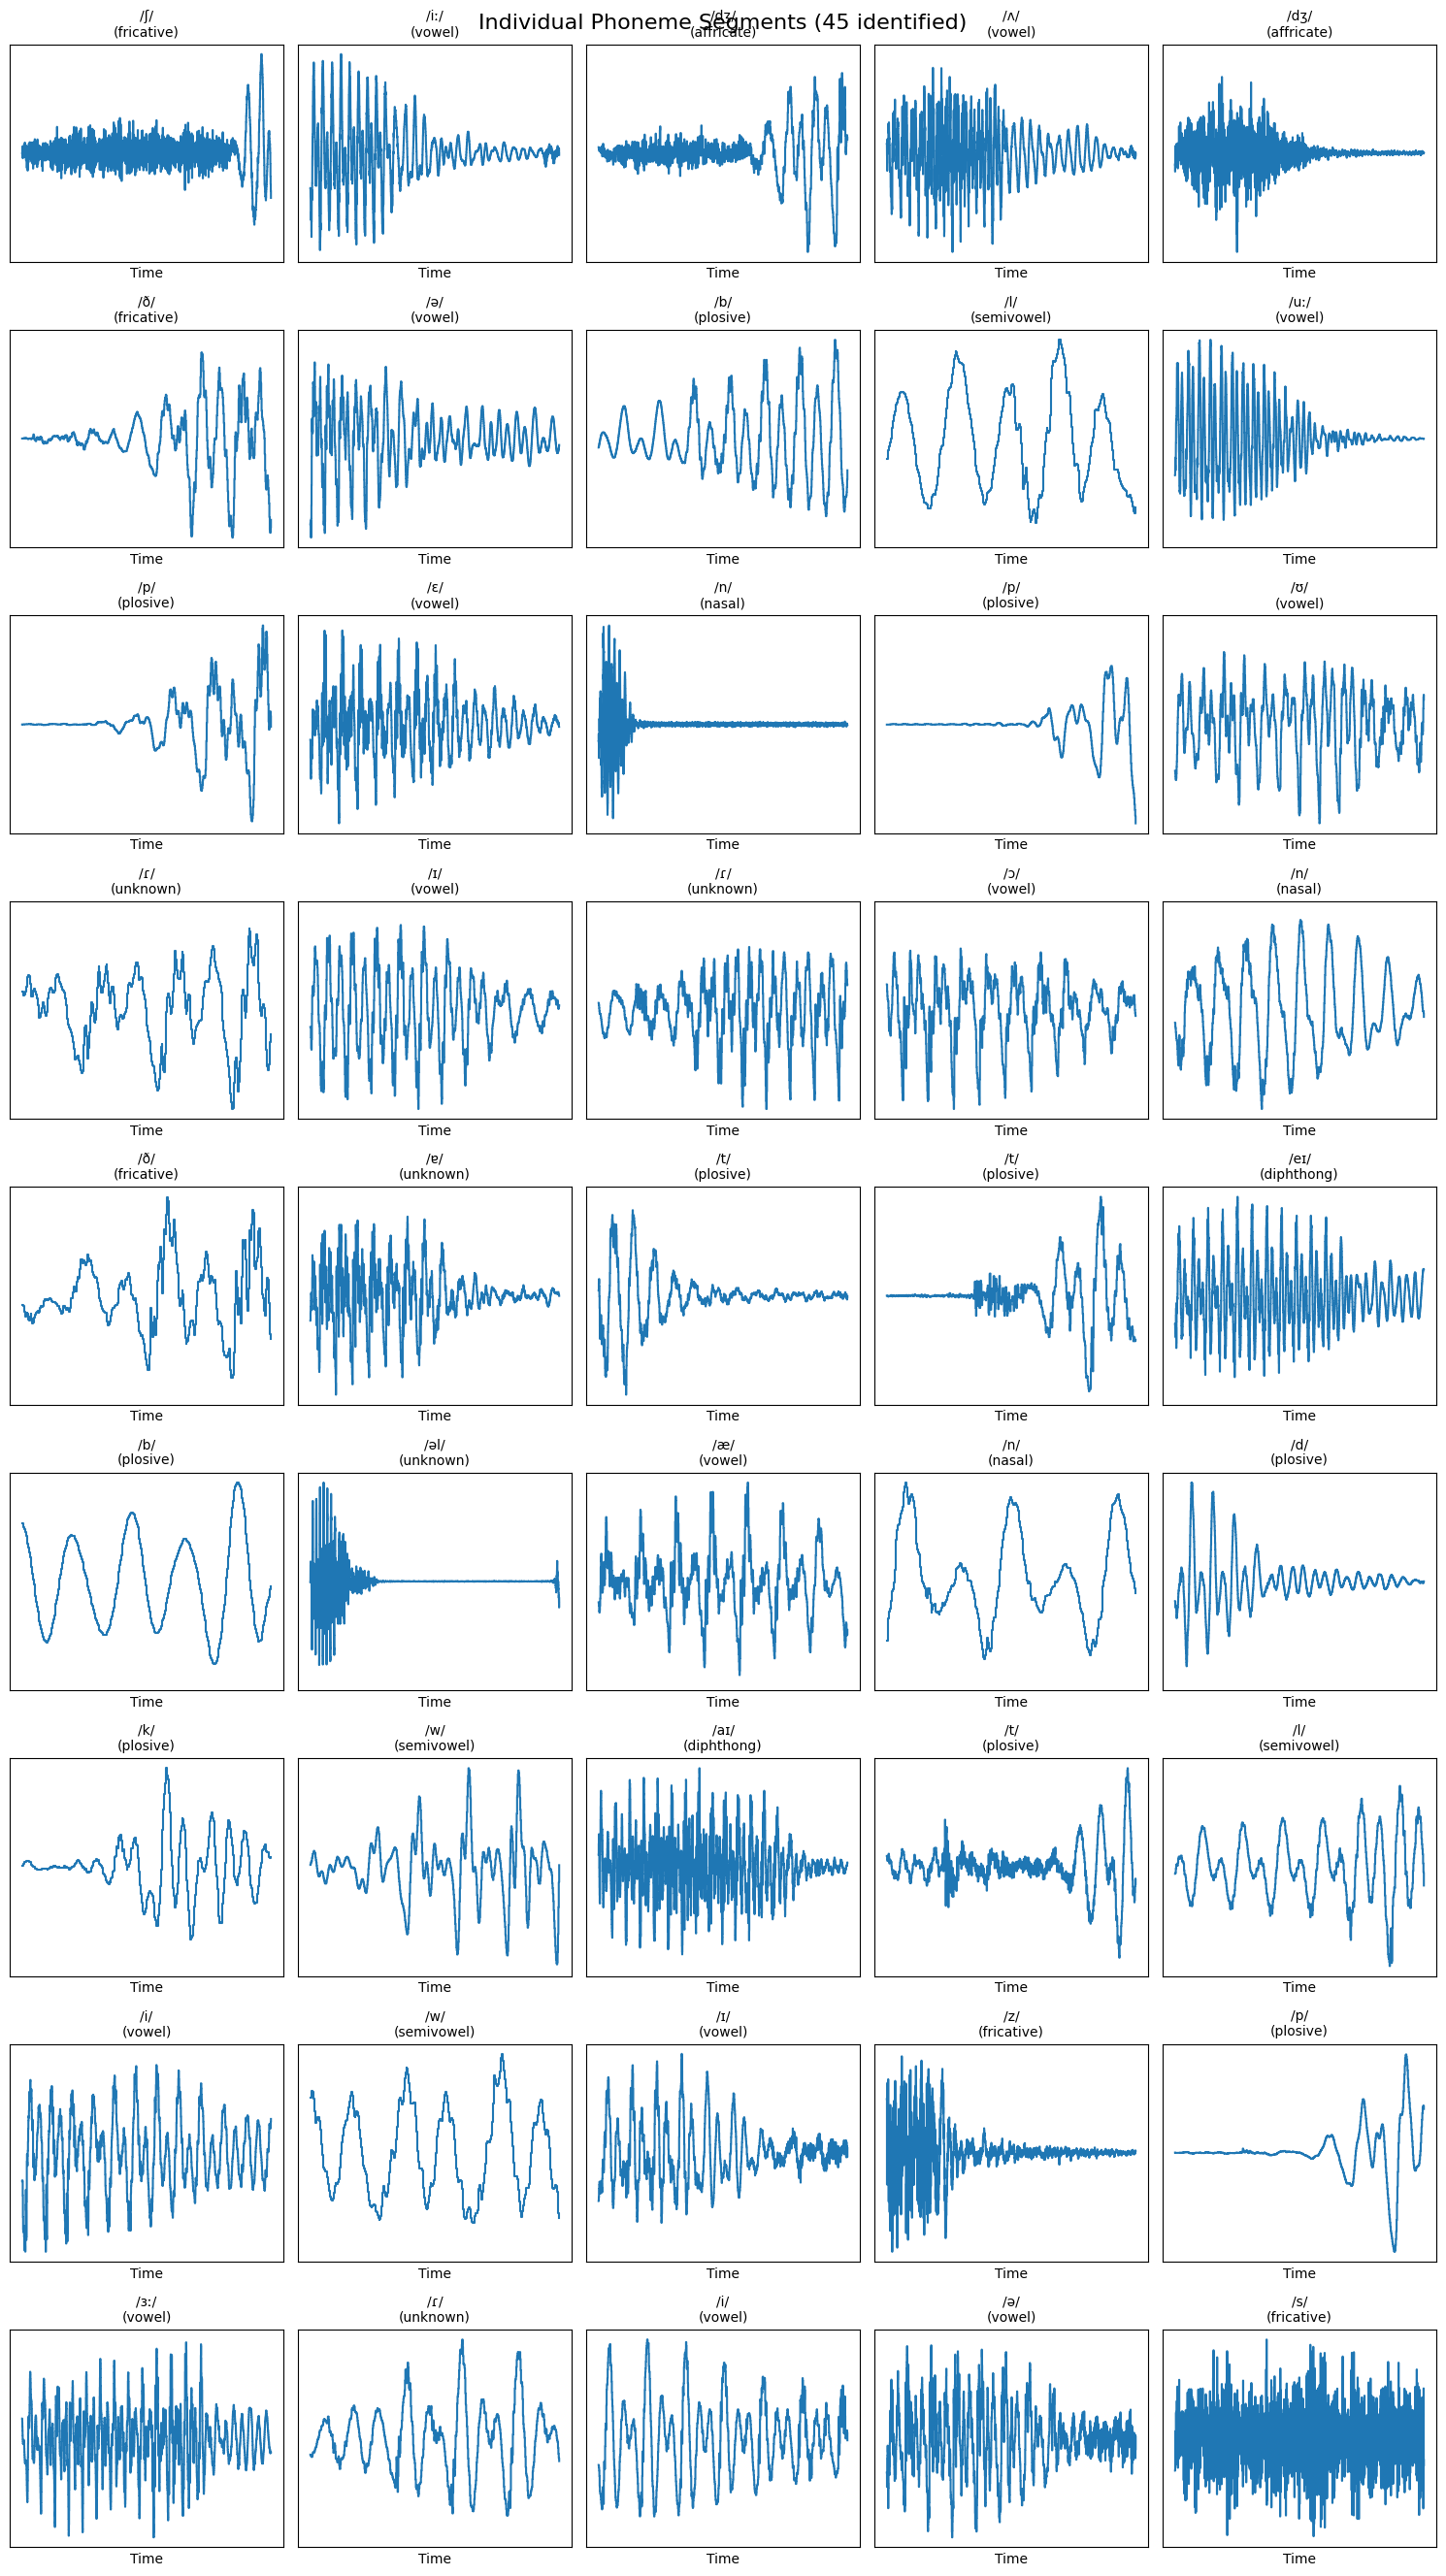


--- Voiced/Unvoiced Comparison ---
Voiced Segment: 'iː' (vowel) at 0.98s
Unvoiced Segment: 'ʃ' (fricative) at 0.88s


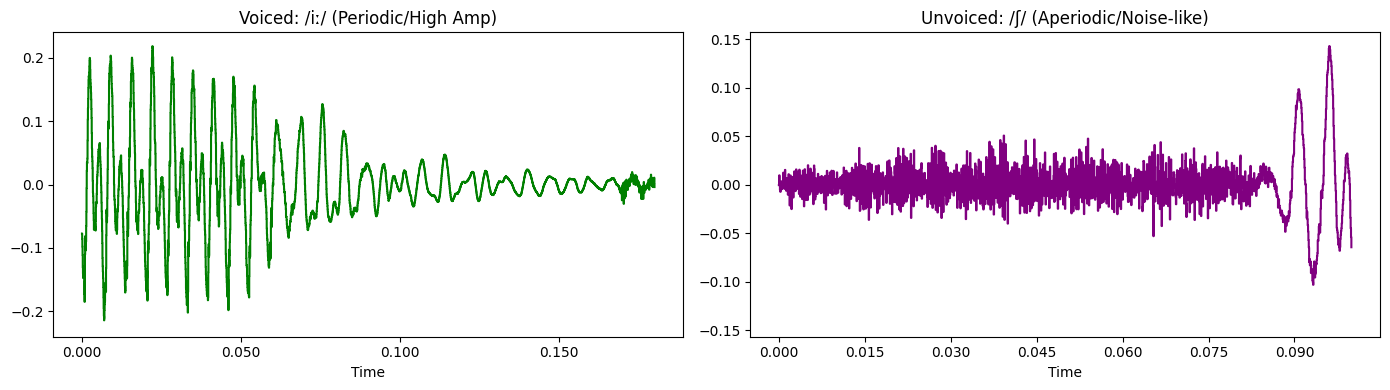

In [ ]:
# ==========================================
# OBJECTIVE 1: PHONEME SEGMENTATION & VOICING ANALYSIS
# ==========================================

# 1. INSTALLATION & IMPORTS
# ------------------------------------------
!pip install torch torchaudio librosa transformers matplotlib phonemizer

import torch
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC, Wav2Vec2CTCTokenizer, Wav2Vec2FeatureExtractor
import os

# 2. CONFIGURATION
# ------------------------------------------
FILE_PATH = "objective1.wav"

MODEL_NAME = "facebook/wav2vec2-lv-60-espeak-cv-ft"
print(f"Loading model: {MODEL_NAME}...")
# Explicitly load components to avoid TypeError in some transformer versions
tokenizer = Wav2Vec2CTCTokenizer.from_pretrained(MODEL_NAME)
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(MODEL_NAME)
processor = Wav2Vec2Processor(feature_extractor=feature_extractor, tokenizer=tokenizer)
model = Wav2Vec2ForCTC.from_pretrained(MODEL_NAME)

# 3. HELPER: PHONEME CATEGORIZATION (Simplified Mapping)
# ------------------------------------------
# This maps common IPA symbols to broad categories
PHONEME_MAP = {
    'vowel': ['i', 'i:', 'ɪ', 'e', 'ɛ', 'æ', 'a', 'ɑ', 'ɑ:', 'ɒ', 'ɔ', 'ɔ:', 'o', 'ʊ', 'u', 'u:', 'ʌ', 'ɜ', 'ɜ:', 'ə'],
    'diphthong': ['eɪ', 'aɪ', 'ɔɪ', 'aʊ', 'əʊ', 'ɪə', 'eə', 'ʊə'],
    'plosive': ['p', 'b', 't', 'd', 'k', 'g', 'ʔ'],
    'fricative': ['f', 'v', 'θ', 'ð', 's', 'z', 'ʃ', 'ʒ', 'h'],
    'affricate': ['tʃ', 'dʒ', 'ʧ', 'ʤ'],
    'nasal': ['m', 'n', 'ŋ'],
    'semivowel': ['j', 'w', 'ɹ', 'l']
}

def get_category(phoneme):
    # Clean phoneme string (remove stress markers like ˈ or ˌ)
    p_clean = phoneme.replace('ˈ', '').replace('ˌ', '').replace('ː', '')
    for cat, p_list in PHONEME_MAP.items():
        if p_clean in p_list or phoneme in p_list:
            return cat
    return "unknown"

# 4. MAIN PROCESSING
# ------------------------------------------
if os.path.exists(FILE_PATH):
    print(f"Processing: {os.path.basename(FILE_PATH)}")
    speech, sr = librosa.load(FILE_PATH, sr=16000)

    # Inference
    input_values = processor(speech, return_tensors="pt", sampling_rate=16000).input_values
    with torch.no_grad():
        logits = model(input_values).logits

    predicted_ids = torch.argmax(logits, dim=-1)
    transcription = processor.batch_decode(predicted_ids)

    # Time offset calc
    time_offset = model.config.inputs_to_logits_ratio / processor.feature_extractor.sampling_rate

    # Extract phoneme events
    phoneme_events = []
    raw_ids = predicted_ids[0].tolist()
    prev_token = None

    for i, token_id in enumerate(raw_ids):
        if token_id != 0 and token_id != processor.tokenizer.pad_token_id:
            if token_id != prev_token:
                p_char = processor.decode(token_id)
                cat = get_category(p_char)
                phoneme_events.append({
                    "phoneme": p_char,
                    "category": cat,
                    "time": i * time_offset,
                    "index": len(phoneme_events)
                })
            prev_token = token_id
        else:
            prev_token = token_id

    print(f"\nDetected {len(phoneme_events)} phonemes.")
    print("Sequence:", " ".join([p['phoneme'] for p in phoneme_events]))

    # 5. VISUALIZATION (Full Sequence)
    # ------------------------------------------
    plt.figure(figsize=(18, 6))
    librosa.display.waveshow(speech, sr=sr, alpha=0.5, color='gray')

    for i, event in enumerate(phoneme_events):
        t = event['time']
        plt.axvline(x=t, color='r', linestyle=':', alpha=0.5)
        # Alternate label height
        y = 0.8 if i % 2 == 0 else 0.6
        plt.text(t, np.max(speech)*y, f"{event['phoneme']}\n({event['category']})",
                 fontsize=8, color='blue', rotation=90)

    plt.title("Phoneme Segmentation & Categorization (Full Audio)")
    plt.xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

    # 6. EXTRACT ALL PHONEME SEGMENTS (Grid View)
    # ------------------------------------------
    print("\n--- EXTRACTING ALL INDIVIDUAL SEGMENTS ---")
    n_phonemes = len(phoneme_events)
    cols = 5
    rows = (n_phonemes + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
    # Handle array flattening
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    for i in range(len(axes)):
        if i < n_phonemes:
            p = phoneme_events[i]
            # Calculate duration
            if i + 1 < n_phonemes:
                end_time = phoneme_events[i+1]['time']
            else:
                end_time = p['time'] + 0.1

            start_sample = int(p['time'] * sr)
            end_sample = int(end_time * sr)

            # Bound checks
            if end_sample > len(speech): end_sample = len(speech)

            segment = speech[start_sample:end_sample]

            librosa.display.waveshow(segment, sr=sr, ax=axes[i])
            axes[i].set_title(f"/{p['phoneme']}/\n({p['category']})", fontsize=10)
            axes[i].set_xticks([]) # Remove x-axis time ticks for cleanliness
            axes[i].set_yticks([])
        else:
            axes[i].axis('off')

    plt.suptitle(f"Individual Phoneme Segments ({n_phonemes} identified)", fontsize=16)
    plt.tight_layout()
    plt.show()

    # 7. SPECIFIC COMPARISON (Voiced vs Unvoiced)
    # ------------------------------------------
    # Try to find specific examples based on the sentence
    voiced_target = next((p for p in phoneme_events if p['phoneme'] in ['d', 'b', 'z', 'm', 'n'] or p['category'] == 'vowel'), None)
    unvoiced_target = next((p for p in phoneme_events if p['phoneme'] in ['s', 't', 'p', 'k', 'ʃ', 'h']), None)

    if voiced_target and unvoiced_target:
        print(f"\n--- Voiced/Unvoiced Comparison ---")
        print(f"Voiced Segment: '{voiced_target['phoneme']}' ({voiced_target['category']}) at {voiced_target['time']:.2f}s")
        print(f"Unvoiced Segment: '{unvoiced_target['phoneme']}' ({unvoiced_target['category']}) at {unvoiced_target['time']:.2f}s")

        # Helper to extract segment
        def extract_seg(event):
            start = int(event['time'] * sr)
            if event['index'] + 1 < len(phoneme_events):
                end = int(phoneme_events[event['index']+1]['time'] * sr)
            else:
                end = int((event['time'] + 0.1) * sr)
            return speech[start:end]

        v_seg = extract_seg(voiced_target)
        uv_seg = extract_seg(unvoiced_target)

        # Plot comparison
        fig, ax = plt.subplots(1, 2, figsize=(14, 4))

        # Voiced Plot
        librosa.display.waveshow(v_seg, sr=sr, ax=ax[0], color='green')
        ax[0].set_title(f"Voiced: /{voiced_target['phoneme']}/ (Periodic/High Amp)")
        ax[0].set_xlabel("Time")

        # Unvoiced Plot
        librosa.display.waveshow(uv_seg, sr=sr, ax=ax[1], color='purple')
        ax[1].set_title(f"Unvoiced: /{unvoiced_target['phoneme']}/ (Aperiodic/Noise-like)")
        ax[1].set_xlabel("Time")

        plt.tight_layout()
        plt.show()
    else:
        print("Could not automatically find suitable voiced/unvoiced candidates.")

else:
    print(f"File not found: {FILE_PATH}. Please record audio and named it '{FILE_PATH}'.")